# CNN Classification Model to Investigate Cell Image Types

### Importing required libraries

In [1]:
import pickle
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import numpy as np
from tqdm import tqdm
import seaborn as sns
import torchvision.models as models

### Setting up the GPU Device

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:0


### Setting the seed for reproducibility

In [3]:
SEED = 35  # Random seed for reproducibility

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(False)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

## Data Preparation

### Extracting labels and determining number of classes

In [5]:
# Configuration

pkl_directory = "imaging/dataset_extraction/cell_dataset/" # The PKL Directory
TARGET_H, TARGET_W = 224, 224  # Target dimension of 224 for resizing images - it is the standard for ResNet
USE_GRAYSCALE = False  # Whether to use grayscale images
BATCH_SIZE = 64  # Batch size for training
NUM_WORKERS = 4

In [6]:
cell_labels = []
cell_images = []
for pkl_file in Path(pkl_directory).glob("*.pkl"):
   with open(pkl_file, "rb") as f:
      entry = pickle.load(f)

   cell_labels.extend(entry["labels"])
   cell_images.extend(entry["data"])

In [7]:
y = np.asarray(cell_labels, dtype=np.int64)
num_classes = int(np.max(y)) + 1
print(f"Number of classes: {num_classes}")

Number of classes: 3


In [8]:
idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]
idx_2 = np.where(y == 2)[0]
target_n = min(len(idx_0), len(idx_1), len(idx_2))

rng = np.random.default_rng(SEED)
selected_idx_0 = rng.choice(idx_0, size=target_n, replace=False)
selected_idx_1 = rng.choice(idx_1, size=target_n, replace=False)
selected_idx_2 = rng.choice(idx_2, size=target_n, replace=False)

selected_indices = np.concatenate([selected_idx_0, selected_idx_1, selected_idx_2])
rng.shuffle(selected_indices)
X = [cell_images[i] for i in selected_indices]
y = y[selected_indices]

In [9]:
print(f"Total samples after balancing: {len(X)}")

Total samples after balancing: 19866


### Defining the Dataset class and Building the Dataset

In [10]:
class CellsDataset(Dataset):
    def __init__(self, images, labels, transform=None, grayscale=USE_GRAYSCALE):
        self.images = images
        self.labels = labels
        self.transform = transform

        base = []
        base += [T.ToPILImage()]
        base += [T.Resize((TARGET_H, TARGET_W), antialias=True)]
        
        if grayscale:
            base += [T.Grayscale(num_output_channels=1)]
        
        if self.transform:
            base += [
                T.RandomHorizontalFlip(p = 0.5),
                T.RandomVerticalFlip(p = 0.3),
            ]
        
        base += [T.ToTensor()]
        base += [T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])] # ImageNet normalization
        self.to_tensor = T.Compose(base)
    
        
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform is not None:
            image = self.to_tensor(image)
        y = int(self.labels[idx])
        return image, y

In [11]:
# Stratified Split into Train, Validation, and Test Sets (Stratification helps maintain class distribution across splits)

idx = np.arange(len(y))
train_idx, temp_idx, y_train, y_temp = train_test_split(idx, y, test_size=0.3, random_state=SEED, stratify=y)
val_idx, test_idx, y_val, y_test = train_test_split(temp_idx, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

In [12]:
# Defining the datasets

train_dataset = CellsDataset(
    images=[X[i] for i in train_idx],
    labels=y_train,
    transform=True,
    grayscale=USE_GRAYSCALE
)

val_dataset = CellsDataset(
    images=[X[i] for i in val_idx],
    labels=y_val,
    transform=False,
    grayscale=USE_GRAYSCALE
)

test_dataset = CellsDataset(
    images=[X[i] for i in test_idx],
    labels=y_test,
    transform=False,
    grayscale=USE_GRAYSCALE
)

In [13]:
# Using a WeightedRandomSampler to handle class imbalance in the training dataset
class_counts = Counter(y_train)
class_weights = torch.tensor([1.0 / class_counts[i] for i in range(num_classes)], dtype=torch.float)
sample_weights = torch.tensor([class_weights[label] for label in y_train], dtype=torch.float)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

In [14]:
# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [15]:
print("Train Counts:", Counter(y_train))
print("Validation Counts:", Counter(y_val))
print("Test Counts:", Counter(y_test))

Train Counts: Counter({np.int64(0): 4636, np.int64(1): 4635, np.int64(2): 4635})
Validation Counts: Counter({np.int64(1): 994, np.int64(0): 993, np.int64(2): 993})
Test Counts: Counter({np.int64(2): 994, np.int64(0): 993, np.int64(1): 993})


## Model Definition

In [16]:
weights = models.GoogLeNet_Weights.IMAGENET1K_V1
model = models.googlenet(weights=weights, aux_logits = True)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

if model.aux_logits:
    in_features_aux1 = model.aux1.fc2.in_features
    model.aux1.fc2 = nn.Linear(in_features_aux1, num_classes)
    
    in_features_aux2 = model.aux2.fc2.in_features
    model.aux2.fc2 = nn.Linear(in_features_aux2, num_classes)

model = model.to(device)

/home/kakuly/iris-layout/.venv/lib/python3.10/site-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


In [17]:
def print_metrics(y_true, y_pred, label=""):
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0, 1, 2])
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    print(f"\n{label} metrics:")
    for cls in [0, 1, 2]:
        tp = ((y_true == cls) & (y_pred == cls)).sum()
        fp = ((y_true != cls) & (y_pred == cls)).sum()
        fn = ((y_true == cls) & (y_pred != cls)).sum()
        print(f"Class {cls}:")
        print(f"  TP={tp}, FP={fp}, FN={fn}")
        print(f"  Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision[cls]:.4f}")
        print(f"  Recall    = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall[cls]:.4f}")
        print(f"  F1        = 2 * (P*R)/(P+R) = 2*({precision[cls]:.4f}*{recall[cls]:.4f})/({precision[cls]:.4f}+{recall[cls]:.4f}) = {f1[cls]:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall:    {recall_macro:.4f}")
    print(f"Macro F1:        {f1_macro:.4f}")


In [18]:
def train_loop(model, dataloader, criterion, optimizer, device, epoch):
    model.train()
    running_loss, correct = 0.0, 0
    train_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Train]", leave=False)
    y_true_train, y_pred_train = [], []
    for inputs, labels in train_iter:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        if isinstance(outputs, tuple):
            logits, aux1_logits, aux2_logits = outputs  # Main output and auxiliary outputs
            loss1 = criterion(logits, labels)
            loss2 = criterion(aux1_logits, labels)
            loss3 = criterion(aux2_logits, labels)
            loss = loss1 + 0.3 * (loss2 + loss3)  # Weighted sum of losses
        else:
            logits = outputs
            loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Train Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_train, y_pred_train))
    return epoch_loss

In [19]:
def validation_loop(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss, correct = 0.0, 0
    val_iter = tqdm(dataloader, desc=f"Epoch {epoch:03d} [Val]", leave=False)
    y_true_val, y_pred_val = [], []
    with torch.no_grad():
        for inputs, labels in val_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_val.extend(labels.cpu().numpy())
            y_pred_val.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Validation Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_val, y_pred_val))
    return epoch_loss

In [20]:
def test_loop(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct = 0.0, 0
    test_iter = tqdm(dataloader, desc=f"[Test]", leave=False)
    y_true_test, y_pred_test = [], []
    with torch.no_grad():
        for inputs, labels in test_iter:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            running_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(pred.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset), correct / len(dataloader.dataset)
    print(f"Test Loss: {epoch_loss[0]:.4f}, Accuracy: {epoch_loss[1]:.4f}")
    print(classification_report(y_true_test, y_pred_test))
    print_metrics(np.array(y_true_test), np.array(y_pred_test), label="Test")
    
    sns.heatmap(confusion_matrix(y_true_test, y_pred_test), annot=True, fmt="d")
    plt.title('Confusion Matrix', fontsize=17, pad=20)
    plt.gca().xaxis.set_label_position('top') 
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.gca().xaxis.tick_top()
    plt.gca().figure.subplots_adjust(bottom=0.2)
    
    plt.show()
    return epoch_loss

In [21]:
class EarlyStopping:
    def __init__(self, patience = 5, min_delta = 0.0, mode = 'max', restore_best_weights = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_path = "GoogLeNet_best_model.pth"
    
    def is_improved(self, current_score):
        if self.best_score is None:
            return True
        if self.mode == 'max':
            return current_score > self.best_score + self.min_delta
        else: # in the case of 'min'
            return current_score < self.best_score - self.min_delta
        
    def step(self, current_score, model):
        if self.is_improved(current_score):
            self.best_score = current_score
            self.counter = 0
            torch.save(model.state_dict(), self.best_path)
        else:
            self.counter += 1
            return self.counter >= self.patience
        
    def restore_weights(self, model, map_location=None):
        if self.restore_best_weights and self.best_score is not None:
            model.load_state_dict(torch.load(self.best_path, map_location=map_location))
        

## Using the Model

In [22]:
# Defining model, criterion, and optimizer
counts = torch.tensor([Counter(y_train)[i] for i in range(num_classes)], dtype=torch.float)
weights = (1.0 / counts).clamp(max = (1.0 / counts.min()))
criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

In [23]:
xb, yb = next(iter(train_loader))
print("Batch x shape:", xb.shape)
print("Batch y shape:", yb.shape)
out = model(xb.to(device))
if isinstance(out, tuple):
    print("Output shapes:", [o.shape for o in out])
else:
    print("Output shape:", out.shape)


Batch x shape: torch.Size([64, 3, 224, 224])
Batch y shape: torch.Size([64])
Output shapes: [torch.Size([64, 3]), torch.Size([64, 3]), torch.Size([64, 3])]


In [47]:
# TRAINING

EPOCHS = 50
best_val = -float('inf')
best_epoch = 0
stopper = EarlyStopping(patience=5, min_delta=1e-4, mode='max', restore_best_weights=True)

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss = train_loop(model, train_loader, criterion, optimizer, device, epoch)
    val_loss = validation_loop(model, val_loader, criterion, device, epoch)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss[0]:.4f}, Train Acc: {train_loss[1]:.4f} | Val Loss: {val_loss[0]:.4f}, Val Acc: {val_loss[1]:.4f}")

    if val_loss[1] > best_val:
        best_val = val_loss[1]
        best_epoch = epoch
        print(f"New best model found at epoch {epoch}")
    
    if stopper.step(val_loss[1], model):
        print(f"Early stopping at epoch {epoch}: Best epoch was {best_epoch} with validation accuracy {best_val:.4f}.")
        stopper.restore_weights(model, map_location=device)
        break
    
    
print(f"Training complete. Best validation accuracy: {best_val:.4f} at epoch {best_epoch}")

Epoch 1/50


Train Loss: 0.7630, Accuracy: 0.8052
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      4720
           1       0.72      0.73      0.72      4572
           2       0.78      0.72      0.75      4614

    accuracy                           0.81     13906
   macro avg       0.80      0.80      0.80     13906
weighted avg       0.80      0.81      0.80     13906



Validation Loss: 0.4791, Accuracy: 0.7886
              precision    recall  f1-score   support

           0       0.95      0.83      0.89       993
           1       0.70      0.73      0.72       994
           2       0.74      0.81      0.77       993

    accuracy                           0.79      2980
   macro avg       0.80      0.79      0.79      2980
weighted avg       0.80      0.79      0.79      2980

Epoch 01 | Train Loss: 0.7630, Train Acc: 0.8052 | Val Loss: 0.4791, Val Acc: 0.7886
New best model found at epoch 1
Epoch 2/50


Train Loss: 0.5598, Accuracy: 0.8501
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4720
           1       0.80      0.74      0.77      4592
           2       0.81      0.82      0.81      4594

    accuracy                           0.85     13906
   macro avg       0.85      0.85      0.85     13906
weighted avg       0.85      0.85      0.85     13906



Validation Loss: 0.4027, Accuracy: 0.8097
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       993
           1       0.94      0.50      0.65       994
           2       0.67      0.96      0.79       993

    accuracy                           0.81      2980
   macro avg       0.85      0.81      0.80      2980
weighted avg       0.85      0.81      0.80      2980

Epoch 02 | Train Loss: 0.5598, Train Acc: 0.8501 | Val Loss: 0.4027, Val Acc: 0.8097
New best model found at epoch 2
Epoch 3/50


...

Validation Loss: 0.2986, Accuracy: 0.8658
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       993
           1       0.81      0.79      0.80       994
           2       0.82      0.82      0.82       993

    accuracy                           0.87      2980
   macro avg       0.86      0.87      0.87      2980
weighted avg       0.86      0.87      0.87      2980

Epoch 12 | Train Loss: 0.2923, Train Acc: 0.9282 | Val Loss: 0.2986, Val Acc: 0.8658
Epoch 13/50


Train Loss: 0.3041, Accuracy: 0.9240
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4651
           1       0.89      0.88      0.89      4663
           2       0.90      0.90      0.90      4592

    accuracy                           0.92     13906
   macro avg       0.92      0.92      0.92     13906
weighted avg       0.92      0.92      0.92     13906



Validation Loss: 0.3400, Accuracy: 0.8534
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       993
           1       0.79      0.78      0.78       994
           2       0.80      0.83      0.81       993

    accuracy                           0.85      2980
   macro avg       0.85      0.85      0.85      2980
weighted avg       0.85      0.85      0.85      2980

Epoch 13 | Train Loss: 0.3041, Train Acc: 0.9240 | Val Loss: 0.3400, Val Acc: 0.8534
Epoch 14/50


Train Loss: 0.2903, Accuracy: 0.9272
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4675
           1       0.89      0.89      0.89      4598
           2       0.90      0.90      0.90      4633

    accuracy                           0.93     13906
   macro avg       0.93      0.93      0.93     13906
weighted avg       0.93      0.93      0.93     13906



Validation Loss: 0.5009, Accuracy: 0.7903
              precision    recall  f1-score   support

           0       0.97      0.81      0.88       993
           1       0.67      0.87      0.76       994
           2       0.80      0.69      0.74       993

    accuracy                           0.79      2980
   macro avg       0.81      0.79      0.79      2980
weighted avg       0.81      0.79      0.79      2980

Epoch 14 | Train Loss: 0.2903, Train Acc: 0.9272 | Val Loss: 0.5009, Val Acc: 0.7903
Early stopping at epoch 14: Best epoch was 9 with validation accuracy 0.8718.
Training complete. Best validation accuracy: 0.8718 at epoch 9


Test Loss: 0.2748, Accuracy: 0.8758
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       993
           1       0.82      0.80      0.81       993
           2       0.84      0.85      0.85       994

    accuracy                           0.88      2980
   macro avg       0.88      0.88      0.88      2980
weighted avg       0.88      0.88      0.88      2980


Test metrics:
Class 0:
  TP=967, FP=37, FN=26
  Precision = TP / (TP + FP) = 967 / (967 + 37) = 0.9631
  Recall    = TP / (TP + FN) = 967 / (967 + 26) = 0.9738
  F1        = 2 * (P*R)/(P+R) = 2*(0.9631*0.9738)/(0.9631+0.9738) = 0.9685
Class 1:
  TP=794, FP=169, FN=199
  Precision = TP / (TP + FP) = 794 / (794 + 169) = 0.8245
  Recall    = TP / (TP + FN) = 794 / (794 + 199) = 0.7996
  F1        = 2 * (P*R)/(P+R) = 2*(0.8245*0.7996)/(0.8245+0.7996) = 0.8119
Class 2:
  TP=849, FP=164, FN=145
  Precision = TP / (TP + FP) = 849 / (849 + 164) = 0.8381
  Recall    = TP / (TP + FN) =

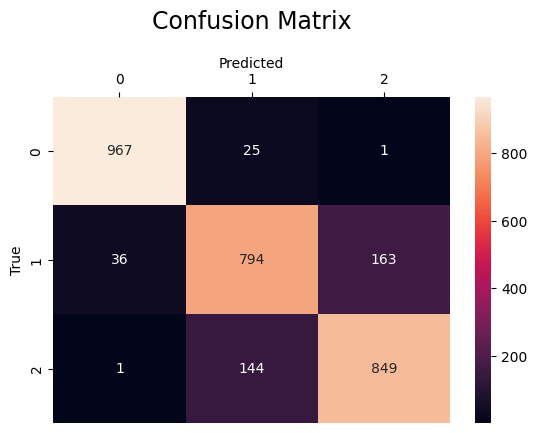

Test Loss: 0.2748, Test Accuracy: 0.8758


In [24]:
# Load the best model for testing

model.load_state_dict(torch.load("GoogLeNet_best_model.pth"))
test_loss = test_loop(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss[0]:.4f}, Test Accuracy: {test_loss[1]:.4f}")

Test Loss: 0.2041, Accuracy: 0.9130
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4719
           1       0.88      0.86      0.87      4573
           2       0.88      0.89      0.89      4614

    accuracy                           0.91     13906
   macro avg       0.91      0.91      0.91     13906
weighted avg       0.91      0.91      0.91     13906


Test metrics:
Class 0:
  TP=4666, FP=108, FN=53
  Precision = TP / (TP + FP) = 4666 / (4666 + 108) = 0.9774
  Recall    = TP / (TP + FN) = 4666 / (4666 + 53) = 0.9888
  F1        = 2 * (P*R)/(P+R) = 2*(0.9774*0.9888)/(0.9774+0.9888) = 0.9830
Class 1:
  TP=3921, FP=556, FN=652
  Precision = TP / (TP + FP) = 3921 / (3921 + 556) = 0.8758
  Recall    = TP / (TP + FN) = 3921 / (3921 + 652) = 0.8574
  F1        = 2 * (P*R)/(P+R) = 2*(0.8758*0.8574)/(0.8758+0.8574) = 0.8665
Class 2:
  TP=4109, FP=546, FN=505
  Precision = TP / (TP + FP) = 4109 / (4109 + 546) = 0.8827
  Recall    = T

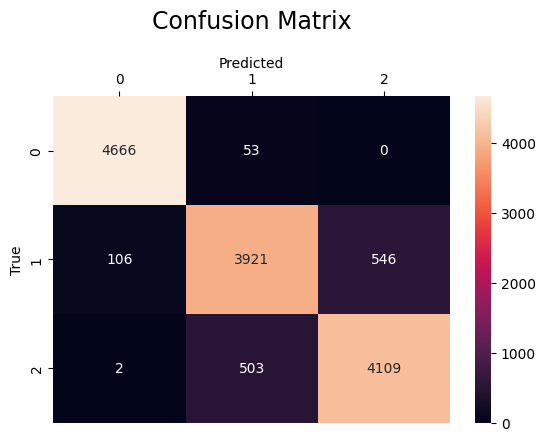

Train Loss: 0.2041, Train Accuracy: 0.9130


In [25]:
# Load the best model for testing

model.load_state_dict(torch.load("GoogLeNet_best_model.pth"))
train_loss = test_loop(model, train_loader, criterion, device)
print(f"Train Loss: {train_loss[0]:.4f}, Train Accuracy: {train_loss[1]:.4f}")

Test Loss: 0.2834, Accuracy: 0.8718
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       993
           1       0.83      0.78      0.80       994
           2       0.82      0.86      0.84       993

    accuracy                           0.87      2980
   macro avg       0.87      0.87      0.87      2980
weighted avg       0.87      0.87      0.87      2980


Test metrics:
Class 0:
  TP=967, FP=30, FN=26
  Precision = TP / (TP + FP) = 967 / (967 + 30) = 0.9699
  Recall    = TP / (TP + FN) = 967 / (967 + 26) = 0.9738
  F1        = 2 * (P*R)/(P+R) = 2*(0.9699*0.9738)/(0.9699+0.9738) = 0.9719
Class 1:
  TP=779, FP=165, FN=215
  Precision = TP / (TP + FP) = 779 / (779 + 165) = 0.8252
  Recall    = TP / (TP + FN) = 779 / (779 + 215) = 0.7837
  F1        = 2 * (P*R)/(P+R) = 2*(0.8252*0.7837)/(0.8252+0.7837) = 0.8039
Class 2:
  TP=852, FP=187, FN=141
  Precision = TP / (TP + FP) = 852 / (852 + 187) = 0.8200
  Recall    = TP / (TP + FN) =

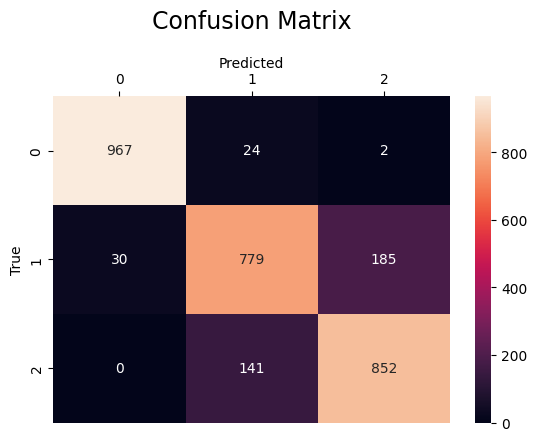

Validation Loss: 0.2834, Validation Accuracy: 0.8718


In [26]:
# Load the best model for testing

model.load_state_dict(torch.load("GoogLeNet_best_model.pth"))
val_loss = test_loop(model, val_loader, criterion, device)
print(f"Validation Loss: {val_loss[0]:.4f}, Validation Accuracy: {val_loss[1]:.4f}")